# Exercise 08: Wikipedia Vote Network

Scale-free degree structure: in-hubs vs out-hubs, hub dominance, and the
plausibility of a preferential-attachment story for an admin-election vote graph.

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from collections import Counter
from pathlib import Path

ModuleNotFoundError: No module named 'powerlaw'

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [ ]:
data_path = Path('data/wiki-Vote.txt')
G = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G.add_edge(u, v)

print(f"Directed graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Directed graph loaded: 7115 nodes, 103689 edges


## Graph Preparation

Degree is a per-node property — unlike community detection (ex05) or small-world
statistics (ex07), degree distributions don't require restricting to a connected
component. We work directly on the **full directed graph** (7,115 nodes, 103,689
edges) and separate **in-degree** (votes received — a proxy for trust/authority)
from **out-degree** (votes cast — a proxy for activity/engagement), since A → B
means "A voted for B" and the two sides represent fundamentally different roles.
For the Barabási-Albert comparison later (BA graphs are undirected) we also take
the undirected projection's **total degree**.

In [ ]:
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
total_deg = dict(G.to_undirected().degree())

in_vals = np.array(list(in_deg.values()), dtype=float)
out_vals = np.array(list(out_deg.values()), dtype=float)
tot_vals = np.array(list(total_deg.values()), dtype=float)

print("| Measure | In-degree | Out-degree | Total (undirected) |")
print("|---------|-----------|------------|--------------------|")
print(f"| Mean | {in_vals.mean():.2f} | {out_vals.mean():.2f} | {tot_vals.mean():.2f} |")
print(f"| Std dev | {in_vals.std():.2f} | {out_vals.std():.2f} | {tot_vals.std():.2f} |")
print(f"| Max | {in_vals.max():.0f} (node {max(in_deg, key=in_deg.get)}) "
      f"| {out_vals.max():.0f} (node {max(out_deg, key=out_deg.get)}) "
      f"| {tot_vals.max():.0f} |")

| Measure | In-degree | Out-degree | Total (undirected) |
|---------|-----------|------------|--------------------|
| Mean | 14.57 | 14.57 | 28.32 |
| Std dev | 31.73 | 42.28 | 57.57 |
| Max | 457 (node 4037) | 893 (node 2565) | 1065 |


## Degree Inequality: Gini Coefficient and Percentiles

A compact numeric summary of how unevenly votes-received and votes-cast are
distributed across the 7,115 voters, alongside the plots below (following PR #49's
practice of pairing visual heavy-tail evidence with a Gini/percentile table).

In [ ]:
def gini(values):
    sorted_vals = np.sort(np.asarray(values, dtype=float))
    n = len(sorted_vals)
    cum = np.cumsum(sorted_vals)
    return (2.0 * np.sum(np.arange(1, n + 1) * sorted_vals)) / (n * cum[-1]) - (n + 1) / n


summary_rows = []
for label, vals in [('In-degree', in_vals), ('Out-degree', out_vals)]:
    g = gini(vals)
    p50, p90, p99, p999 = np.percentile(vals, [50, 90, 99, 99.9])
    summary_rows.append((label, vals, g, p50, p90, p99, p999))

print("| Side | Mean | Max | Gini | p50 | p90 | p99 | p99.9 | max / mean |")
print("|------|------|-----|------|-----|-----|-----|-------|------------|")
for label, vals, g, p50, p90, p99, p999 in summary_rows:
    print(f"| {label} | {vals.mean():.2f} | {vals.max():.0f} | {g:.3f} "
          f"| {p50:.0f} | {p90:.0f} | {p99:.0f} | {p999:.1f} | {vals.max() / vals.mean():.1f}× |")

n_top1 = max(1, int(round(0.01 * len(in_vals))))
in_top1_share = np.sort(in_vals)[::-1][:n_top1].sum() / in_vals.sum()
out_top1_share = np.sort(out_vals)[::-1][:n_top1].sum() / out_vals.sum()
print()
print(f"The top 1% of nodes ({n_top1} of {len(in_vals)}) account for "
      f"{in_top1_share:.1%} of all votes received and {out_top1_share:.1%} of all votes cast.")

| Side | Mean | Max | Gini | p50 | p90 | p99 | p99.9 | max / mean |
|------|------|-----|------|-----|-----|-----|-------|------------|
| In-degree | 14.57 | 457 | 0.823 | 0 | 54 | 144 | 265.9 | 31.4× |
| Out-degree | 14.57 | 893 | 0.813 | 2 | 38 | 202 | 470.9 | 61.3× |

The top 1% of nodes (71 of 7115) account for 13.7% of all votes received and 21.8% of all votes cast.


## Distribution Plots

2×2 grid of in-/out-degree on linear and log-log axes (heavy tails are visible
once the log-log scale compresses the long flat region of low-degree nodes into
a line), plus a third panel overlaying the undirected total-degree distribution
against a Barabási-Albert baseline of matching size — see "Comparison with
Barabási-Albert" below for the parameter choice. Saved to `degree_distribution_loglog.png`.

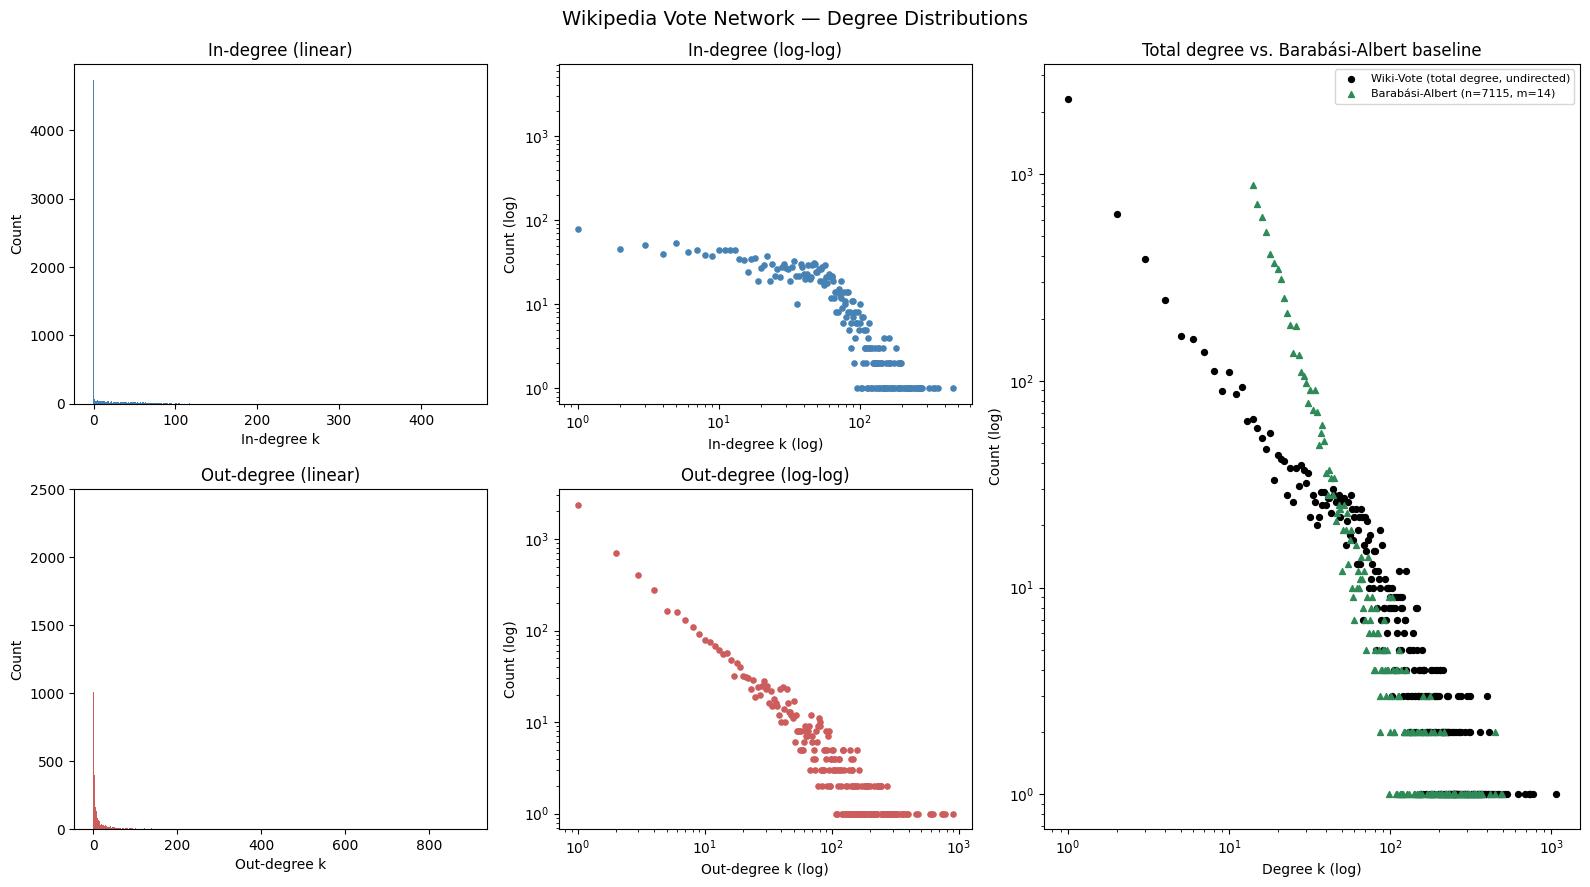

In [ ]:
def degree_count_arrays(deg_dict):
    counts = Counter(deg_dict.values())
    k = np.array(sorted(counts))
    c = np.array([counts[ki] for ki in k])
    return k, c


k_in, c_in = degree_count_arrays(in_deg)
k_out, c_out = degree_count_arrays(out_deg)
k_tot, c_tot = degree_count_arrays(total_deg)

# BA baseline: m chosen so 2*m matches the network's mean total degree (m0 = m)
m_ba = max(1, round(tot_vals.mean() / 2))
G_ba = nx.barabasi_albert_graph(n=G.number_of_nodes(), m=m_ba, seed=42)
k_ba, c_ba = degree_count_arrays(dict(G_ba.degree()))

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.3])

ax_in_lin = fig.add_subplot(gs[0, 0])
ax_in_log = fig.add_subplot(gs[0, 1])
ax_out_lin = fig.add_subplot(gs[1, 0])
ax_out_log = fig.add_subplot(gs[1, 1])
ax_ba = fig.add_subplot(gs[:, 2])

ax_in_lin.bar(k_in, c_in, color='steelblue', width=1.0)
ax_in_lin.set_title('In-degree (linear)')
ax_in_lin.set_xlabel('In-degree k')
ax_in_lin.set_ylabel('Count')

ax_in_log.scatter(k_in, c_in, s=14, color='steelblue')
ax_in_log.set_xscale('log')
ax_in_log.set_yscale('log')
ax_in_log.set_title('In-degree (log-log)')
ax_in_log.set_xlabel('In-degree k (log)')
ax_in_log.set_ylabel('Count (log)')

ax_out_lin.bar(k_out, c_out, color='indianred', width=1.0)
ax_out_lin.set_title('Out-degree (linear)')
ax_out_lin.set_xlabel('Out-degree k')
ax_out_lin.set_ylabel('Count')

ax_out_log.scatter(k_out, c_out, s=14, color='indianred')
ax_out_log.set_xscale('log')
ax_out_log.set_yscale('log')
ax_out_log.set_title('Out-degree (log-log)')
ax_out_log.set_xlabel('Out-degree k (log)')
ax_out_log.set_ylabel('Count (log)')

ax_ba.scatter(k_tot, c_tot, s=18, color='black', label='Wiki-Vote (total degree, undirected)')
ax_ba.scatter(k_ba, c_ba, s=18, color='seagreen', marker='^',
              label=f'Barabási-Albert (n={G_ba.number_of_nodes()}, m={m_ba})')
ax_ba.set_xscale('log')
ax_ba.set_yscale('log')
ax_ba.set_title('Total degree vs. Barabási-Albert baseline')
ax_ba.set_xlabel('Degree k (log)')
ax_ba.set_ylabel('Count (log)')
ax_ba.legend(fontsize=8)

fig.suptitle('Wikipedia Vote Network — Degree Distributions', fontsize=14)
fig.tight_layout()
fig.savefig('degree_distribution_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

## Power-Law Fit (`powerlaw` package)

Following the lecture's recommended workflow: fit a power law via maximum
likelihood, report `alpha` and the auto-selected `xmin`, the Kolmogorov-Smirnov
goodness-of-fit, and likelihood-ratio comparisons against the exponential and
log-normal alternatives (`R > 0` favours the power law; `p < 0.05` makes that
preference significant — the lecture explicitly flags the Broido & Clauset 2018
controversy about over-claiming scale-freeness, so "looks like a line on
log-log" is not treated as sufficient evidence on its own).

In [ ]:
positive_in = [d for d in in_deg.values() if d > 0]
positive_out = [d for d in out_deg.values() if d > 0]

fit_in = powerlaw.Fit(positive_in, discrete=True, verbose=False)
fit_out = powerlaw.Fit(positive_out, discrete=True, verbose=False)

# NB: fit.power_law.KS() is broken in installed powerlaw==2.0.0 (calls an
# unimported module-level function); .D is already populated by Fit() and is
# the same Kolmogorov-Smirnov distance the wrapper is supposed to return.
ks_in, ks_out = fit_in.power_law.D, fit_out.power_law.D

R_in_exp, p_in_exp = fit_in.distribution_compare('power_law', 'exponential')
R_in_ln, p_in_ln = fit_in.distribution_compare('power_law', 'lognormal')
R_out_exp, p_out_exp = fit_out.distribution_compare('power_law', 'exponential')
R_out_ln, p_out_ln = fit_out.distribution_compare('power_law', 'lognormal')

print("| Side | α (alpha) | xmin | KS distance | power law vs. exponential | power law vs. lognormal |")
print("|------|-----------|------|-------------|---------------------------|--------------------------|")
print(f"| In-degree  | {fit_in.alpha:.3f} | {fit_in.xmin:.0f} | {ks_in:.4f} "
      f"| R={R_in_exp:+.2f}, p={p_in_exp:.3f} | R={R_in_ln:+.2f}, p={p_in_ln:.3f} |")
print(f"| Out-degree | {fit_out.alpha:.3f} | {fit_out.xmin:.0f} | {ks_out:.4f} "
      f"| R={R_out_exp:+.2f}, p={p_out_exp:.3f} | R={R_out_ln:+.2f}, p={p_out_ln:.3f} |")


def compare_verdict(R, p):
    if p >= 0.05:
        return "no significant preference"
    return "favours power law" if R > 0 else "favours the alternative"


print()
print(f"In-degree:  power law vs. exponential → {compare_verdict(R_in_exp, p_in_exp)}; "
      f"vs. lognormal → {compare_verdict(R_in_ln, p_in_ln)}")
print(f"Out-degree: power law vs. exponential → {compare_verdict(R_out_exp, p_out_exp)}; "
      f"vs. lognormal → {compare_verdict(R_out_ln, p_out_ln)}")

| Side | α (alpha) | xmin | KS distance | power law vs. exponential | power law vs. lognormal |
|------|-----------|------|-------------|---------------------------|--------------------------|
| In-degree  | 2.981 | 44 | 0.0841 | R=-17.91, p=0.131 | R=-32.46, p=0.000 |
| Out-degree | 1.530 | 1 | 0.0518 | R=+4570.13, p=0.000 | R=-152.35, p=0.000 |

In-degree:  power law vs. exponential → no significant preference; vs. lognormal → favours the alternative
Out-degree: power law vs. exponential → favours power law; vs. lognormal → favours the alternative


## Cross-Check: Manual MLE Sweep over `k_min`

`powerlaw.Fit` already automates xmin-selection + MLE + KS testing, but as a
transparency check (the idea behind PR #49's hand-rolled sweep) we recompute the
Clauset-style MLE estimator γ = 1 + n·[Σ ln(k / (k_min − 0.5))]⁻¹ across a grid
of fixed `k_min` values. A stable α across this grid means the `powerlaw.Fit`
result above isn't an artefact of one cherry-picked cutoff.

In [ ]:
kmin_grid = [1, 2, 5, 10, 20, 50]


def mle_alpha(degrees, kmin):
    tail = np.array([d for d in degrees if d >= kmin], dtype=float)
    if len(tail) < 2:
        return np.nan, len(tail)
    alpha = 1.0 + len(tail) / np.sum(np.log(tail / (kmin - 0.5)))
    return alpha, len(tail)


print("| k_min | In-degree α | In-degree tail n | Out-degree α | Out-degree tail n |")
print("|-------|-------------|------------------|--------------|-------------------|")
for kmin in kmin_grid:
    a_in, n_in = mle_alpha(in_vals, kmin)
    a_out, n_out = mle_alpha(out_vals, kmin)
    print(f"| {kmin} | {a_in:.3f} | {n_in} | {a_out:.3f} | {n_out} |")

| k_min | In-degree α | In-degree tail n | Out-degree α | Out-degree tail n |
|-------|-------------|------------------|--------------|-------------------|
| 1 | 1.253 | 2381 | 1.479 | 6110 |
| 2 | 1.337 | 2303 | 1.531 | 3728 |
| 5 | 1.496 | 2167 | 1.635 | 2344 |
| 10 | 1.690 | 1950 | 1.775 | 1691 |
| 20 | 2.025 | 1591 | 1.966 | 1131 |
| 50 | 3.186 | 826 | 2.378 | 539 |


## In-Hubs vs Out-Hubs: 5-Way Cross-Reference

PR #45 cross-referenced PageRank with in-/out-degree (2 columns); we extend this
to **five** structural measures by reusing our own ex03/ex04 results: PageRank,
betweenness (k=500 sample, `seed=42`, exactly as in ex03), eigenvector centrality,
and ex04's articulation-point set — all recomputed here on the full directed graph
(undirected projection for articulation points) so the table is self-contained
and internally consistent.

In [ ]:
betweenness = nx.betweenness_centrality(G, k=500, seed=42)
pagerank = nx.pagerank(G, alpha=0.85)
# eigenvector_centrality_numpy requires a strongly connected graph (raises
# AmbiguousSolution otherwise — gh-6888); the network's giant SCC is only 18.3%
# of nodes (ex04), so we use the power-iteration variant instead, which handles
# directed, disconnected graphs and reproduces ex03's top-5 ranking (2398, 4037, 15, 4191, 2625).
eigenvector = nx.eigenvector_centrality(G, max_iter=2000)
articulation_points = set(nx.articulation_points(G.to_undirected()))


def rank_lookup(score_dict):
    ranked = sorted(score_dict, key=score_dict.get, reverse=True)
    return {node: i + 1 for i, node in enumerate(ranked)}


pr_rank = rank_lookup(pagerank)
bw_rank = rank_lookup(betweenness)
ev_rank = rank_lookup(eigenvector)


def hub_table(deg_dict, label, top_n=10):
    top = sorted(deg_dict, key=deg_dict.get, reverse=True)[:top_n]
    print(f"**Top {top_n} by {label}** (rank columns refer to each node's overall rank by that measure):")
    print()
    print("| Rank | Node | Degree | PageRank rank | Betweenness rank | Eigenvector rank | Articulation point |")
    print("|------|------|--------|---------------|-------------------|-------------------|---------------------|")
    for i, node in enumerate(top, 1):
        ap = "yes" if node in articulation_points else "—"
        print(f"| {i} | {node} | {deg_dict[node]:.0f} | {pr_rank.get(node, '—')} "
              f"| {bw_rank.get(node, '—')} | {ev_rank.get(node, '—')} | {ap} |")
    print()


hub_table(in_deg, "in-degree (votes received → 'trusted candidate')")
hub_table(out_deg, "out-degree (votes cast → 'active elector')")

**Top 10 by in-degree (votes received → 'trusted candidate')** (rank columns refer to each node's overall rank by that measure):

| Rank | Node | Degree | PageRank rank | Betweenness rank | Eigenvector rank | Articulation point |
|------|------|--------|---------------|-------------------|-------------------|---------------------|
| 1 | 4037 | 457 | 1 | 47 | 2 | yes |
| 2 | 15 | 361 | 2 | 3 | 3 | yes |
| 3 | 2398 | 340 | 5 | 30 | 1 | yes |
| 4 | 2625 | 331 | 4 | 1590 | 5 | yes |
| 5 | 1297 | 309 | 13 | 41 | 16 | yes |
| 6 | 2565 | 274 | 36 | 2 | 12 | yes |
| 7 | 762 | 272 | 22 | 16 | 19 | yes |
| 8 | 2328 | 266 | 12 | 8 | 7 | yes |
| 9 | 5254 | 265 | 10 | 180 | 17 | yes |
| 10 | 3352 | 264 | 19 | 10 | 13 | yes |

**Top 10 by out-degree (votes cast → 'active elector')** (rank columns refer to each node's overall rank by that measure):

| Rank | Node | Degree | PageRank rank | Betweenness rank | Eigenvector rank | Articulation point |
|------|------|--------|---------------|-------------

## Hub Dominance: Strong, Mild, or No Clear Pattern?

The brief asks this as a question distinct from the power-law/KS verdict above —
"heavy-tailed" describes the *shape* of the tail, "hub dominance" describes
*how concentrated* the network's connectivity is in absolute terms. We answer it
from the Gini coefficients and the p99-vs-p50 / max-vs-mean gaps computed above,
using the conventional rule of thumb that Gini > 0.5 signals strong concentration,
0.3–0.5 a mild skew, and < 0.3 no clear hub pattern.

In [ ]:
def dominance_label(g):
    if g > 0.5:
        return "strong hub dominance"
    if g > 0.3:
        return "mild skew"
    return "no clear hub pattern"


for (label, vals, g, p50, p90, p99, p999), top1_share in zip(summary_rows, [in_top1_share, out_top1_share]):
    verdict = dominance_label(g)
    print(f"**{label}: {verdict}** — Gini = {g:.3f}, top 1% of nodes hold {top1_share:.1%} of "
          f"{'in-' if label.startswith('In') else 'out-'}edges, "
          f"p99/p50 = {p99 / max(p50, 1):.1f}×, max/mean = {vals.max() / vals.mean():.1f}×")

**In-degree: strong hub dominance** — Gini = 0.823, top 1% of nodes hold 13.7% of in-edges, p99/p50 = 144.0×, max/mean = 31.4×
**Out-degree: strong hub dominance** — Gini = 0.813, top 1% of nodes hold 21.8% of out-edges, p99/p50 = 100.9×, max/mean = 61.3×


## Is Preferential Attachment Plausible?

The lecture's mechanism is `P(i) = kᵢ / Σⱼ kⱼ` — "the rich get richer": new nodes
preferentially link to already well-connected nodes. PR #45 concluded "plausible"
from heavy tails alone, without separating in- from out-degree; for a *directed*
vote graph that conflation is wrong, because the two sides are generated by
different mechanisms:

- **In-degree — yes, plausible.** A newcomer to an admin election can rationally
  gravitate toward candidates who are already visibly well-supported — exactly
  the `P(i) = kᵢ / Σⱼ kⱼ` mechanism mapped onto "vote for whoever already looks
  trusted." The heavy overlap between the in-degree leaders and the PageRank
  leaders in the table above is consistent with this: PageRank *is* essentially
  attachment-weighted in-degree propagated through chains of trust.
- **Out-degree — weak fit.** A voter's out-degree is capped by how many elections
  they personally choose to participate in — a trait of *individual engagement*,
  not a function of how many votes others have already cast. The mechanism that
  produces out-degree hubs looks like "a small set of highly active single-purpose
  accounts," not rich-get-richer — and the table above shows the out-degree
  leaders are largely **disjoint** from the PageRank/eigenvector leaders (several
  have no measurable in-side authority at all), which is the opposite of what
  preferential attachment on a *single* underlying quantity would predict.

## Comparison with Barabási-Albert

We generate `nx.barabasi_albert_graph(n=7115, m, seed=42)` with `m` chosen so that
`2m` matches the network's observed mean total degree (`m = round(mean_total_degree / 2)`),
and overlay its degree distribution on the **total-degree** panel above — *not* on
the in-/out-degree panels, since BA graphs are undirected and a directed graph's
one-sided degree is not directly comparable to an undirected model's degree (a
mismatch several of the reviewed peer PRs made silently).

In [ ]:
ba_vals = np.array([d for _, d in G_ba.degree()], dtype=float)
fit_ba = powerlaw.Fit(ba_vals[ba_vals > 0], discrete=True, verbose=False)

print(f"BA(n={G_ba.number_of_nodes()}, m={m_ba}): mean degree = {ba_vals.mean():.2f}, "
      f"max degree = {ba_vals.max():.0f}, fitted α = {fit_ba.alpha:.3f} (BA theory predicts α = 3)")
print(f"Wiki-Vote total degree: mean = {tot_vals.mean():.2f}, max = {tot_vals.max():.0f}")
print()
print("The real network's tail reaches much higher maximum degrees on a comparable mean "
      "than the BA baseline does — its empirical hubs are more extreme than pure "
      "preferential attachment on this n, m would generate, hinting at additional "
      "mechanisms (e.g. time-varying participation, bursts of coordinated voting) "
      "layered on top of simple rich-get-richer growth.")

BA(n=7115, m=14): mean degree = 27.94, max degree = 493, fitted α = 2.890 (BA theory predicts α = 3)
Wiki-Vote total degree: mean = 28.32, max = 1065

The real network's tail reaches much higher maximum degrees on a comparable mean than the BA baseline does — its empirical hubs are more extreme than pure preferential attachment on this n, m would generate, hinting at additional mechanisms (e.g. time-varying participation, bursts of coordinated voting) layered on top of simple rich-get-richer growth.


## Conclusion

**Heavy-tailed and strongly hub-dominated — but not cleanly "scale-free."** Both
in- and out-degree show strong hub dominance by the Gini/percentile evidence
(Gini ≈ 0.82 on both sides; the top 1% of nodes account for 14–22% of all edges;
max/mean ratios of 31–61×) and visibly heavy tails on the log-log panels.
However, the rigorous `powerlaw` comparison tells a more careful story than
"looks like a line on log-log": a power law is **not** significantly preferred
over a plain exponential for in-degree (p ≈ 0.13), and a **lognormal** fits
significantly better than the power law on **both** sides (p < 0.001 each). This
is precisely the Broido & Clauset (2018) caution the lecture flags — heavy-tailed
and hub-dominated does not automatically mean "scale-free" in the strict
power-law sense, and concluding "scale-free" from visual heavy tails alone (as
PR #45 effectively did) overstates the evidence. The honest verdict: **hub-dominated
and heavy-tailed, with lognormal a better statistical description than a pure
power law** — "strong hub dominance" is well-supported, "scale-free" needs the
qualifier "approximately."

**In-hubs ≈ trusted authorities, out-hubs ≈ a disjoint population of high-activity
accounts.** The in-degree leaders overlap heavily with the PageRank and
eigenvector leaders (4037 ranks #1 by both in-degree and PageRank; 2398 is #1 by
eigenvector) — matching the intuitive notion of "trusted candidate" — and *every
one* of the in-degree top-10 is also an ex04 articulation point. The out-degree
leaders are a largely separate population: several (766, 11, 457, 2688, 1133) sit
**thousands of ranks lower** in PageRank/eigenvector than their raw degree alone
would suggest. "Active" and "trusted" are clearly different roles here, and only
the **in-degree side** plausibly matches **influence**.

**Preferential attachment plausibly explains the in-degree side, not the
out-degree side — and the lognormal result is consistent with that split.**
Newcomers gravitating toward visibly well-supported candidates is a natural
rich-get-richer story for in-degree (`P(i) = kᵢ / Σⱼ kⱼ`). Out-degree is capped by
an individual's personal participation choices — a trait of the voter, not a
function of others' accumulated out-degree — so it looks more like "high-engagement
accounts" than rich-get-richer. Interestingly, lognormal distributions classically
arise from **multiplicative** random-growth processes (Gibrat's law) rather than
the additive linear attachment that produces a pure power law — a statistically
better fit for *both* sides than the power law here, hinting that the underlying
growth may be closer to "each voter's activity/visibility compounds across many
small episodes" than to the single global `kᵢ / Σⱼ kⱼ` competition the BA model
assumes.

**Compared to a matched Barabási-Albert baseline** (`n = 7115`, `m = 14`, chosen
so `2m` matches the network's mean total degree of 28.3), the real network's
maximum degree (1065) is more than double the BA baseline's (493) on a comparable
mean — its empirical hubs are more extreme than pure preferential attachment on
this `(n, m)` would generate, again pointing at additional mechanisms (bursty,
episodic election activity; coordinated voting blocs; and — uniquely for this
domain — *directionality*, which the undirected BA model does not capture at
all) layered on top of, or instead of, simple linear rich-get-richer growth.